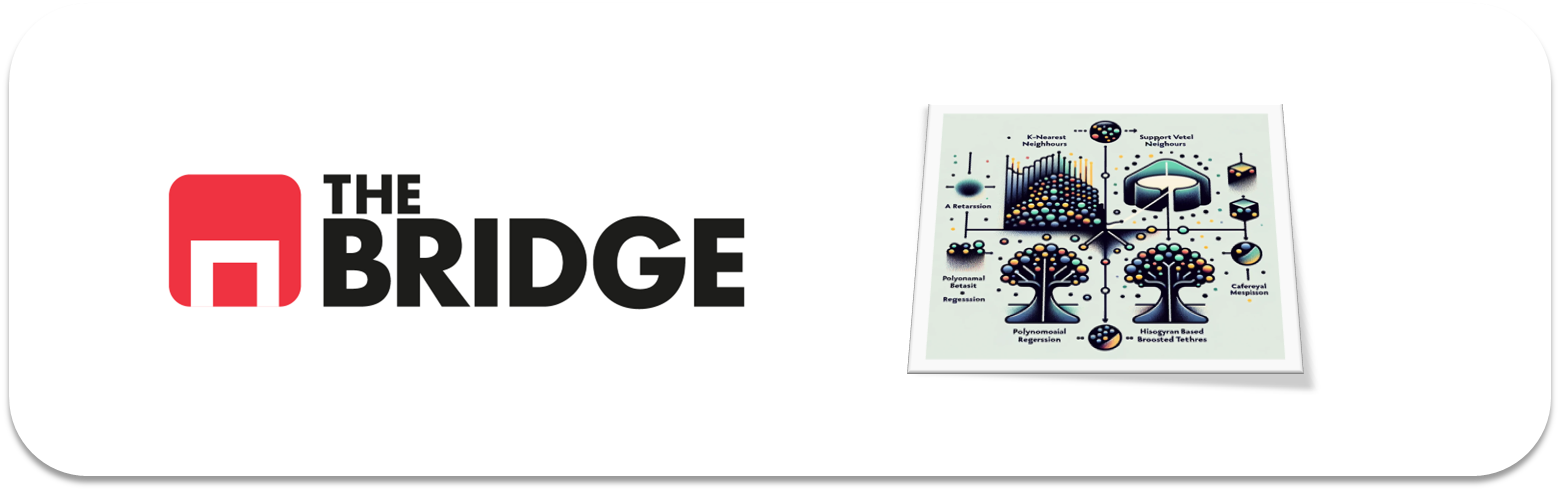

## PRACTICA OBLIGATORIA: **Otros Modelos Supervisados**

* La práctica obligatoria de esta unidad consiste en resolver un modelado de clasificación, incluyendo KNN entre los posibles modelos, y aplicando balanceado. Para ello utilizaremos un dataset que ya hemos empleado en los workout. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import bootcampviztools as bt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bootcampviztools import *
 
from imblearn.over_sampling import SMOTE 
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.utils import resample
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

pd.options.mode.copy_on_write = True



### #1. El problema y los datos

Vamos a volver al dataset con el que vimos la clasificación binaria con regresión logística, "Give me some credit", y nuestro objetivo es crear un modelo que nos permita predicir si una persona va a encontrarse en dificultades financieras en los dos próximos años. El dataset de partida lo puedes en contrar en el directorio data que acompaña al ejercicio. 

### #1.1
Cárgalo y, apoyándote en las herramientas y fuentes que consideres necesarias, haz una descripción textual de sus variables. Luego con ayuda de los datos, haz una clasificación inicial de sus variables en categóricas y numéricas.

In [2]:
df = pd.read_csv("./data/credit_npo.csv")

In [3]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.081892,37,0,0.070709,5656.0,12,1,0,0,0.0
1,0,0.023413,74,0,0.209197,4870.0,9,0,1,0,0.0
2,0,0.000000,43,0,0.080784,5000.0,2,0,0,0,2.0
3,0,0.492754,44,0,0.412735,7333.0,4,0,2,0,3.0
4,0,1.000000,63,0,0.000000,8333.0,3,0,0,0,1.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12537 entries, 0 to 12536
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   SeriousDlqin2yrs                      12537 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  12537 non-null  float64
 2   age                                   12537 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  12537 non-null  int64  
 4   DebtRatio                             12537 non-null  float64
 5   MonthlyIncome                         11816 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       12537 non-null  int64  
 7   NumberOfTimes90DaysLate               12537 non-null  int64  
 8   NumberRealEstateLoansOrLines          12537 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  12537 non-null  int64  
 10  NumberOfDependents                    12360 non-null  float64
dtypes: float64(4), 

- SeriousDlqin2yrs: Variable objetivo. Indica si la persona tuvo dificultades financieras graves (impago) en los próximos 2 años (0 = No, 1 = Sí).

- RevolvingUtilizationOfUnsecuredLines: Ratio de utilización de líneas de crédito no garantizadas (por ejemplo, tarjetas de crédito), respecto al total disponible.

- age: Edad.

- NumberOfTime30-59DaysPastDueNotWorse: Número de veces que el pago se retrasó entre 30 y 59 días.

- DebtRatio: Ratio de deuda mensual respecto a los ingresos brutos mensuales.

- MonthlyIncome: Ingreso mensual.

- NumberOfOpenCreditLinesAndLoans: Número de líneas de crédito y préstamos abiertos (crédito vigente).

- NumberOfTimes90DaysLate: Número de veces que el pago se retrasó 90 días o más.

- NumberRealEstateLoansOrLines: Número de préstamos o líneas de crédito inmobiliario abiertos.

- NumberOfTime60-89DaysPastDueNotWorse: Número de veces que el pago se retrasó entre 60 y 89 días.

- NumberOfDependents: Número de personas dependientes del titular.

In [5]:
# La variable target es SeriousDlqin2yrs que indica si un cliente 
# ha tenido problemas de impagos en los últimos 2 años
df["SeriousDlqin2yrs"].value_counts()



SeriousDlqin2yrs
0    11673
1      864
Name: count, dtype: int64

In [6]:
# La convertimos en categórica BINARIA
df["SeriousDlqin2yrs"] = df["SeriousDlqin2yrs"].astype("category")


### #1.2
¿Qué tipo de problema estamos tratando? ¿Cuál es la variable target?

Se trata de un problema de clasificación binaria en la que la variable target
es SeriousDlqin2yrs que indica si un cliente ha tenido dificultades financieras
en los 2 últimos años


In [7]:
# Renombramos la variable target
df.rename(columns={"SeriousDlqin2yrs": "Target"}, inplace=True)

### #1.3
Pinta la distribución de frecuencias del target y coméntala

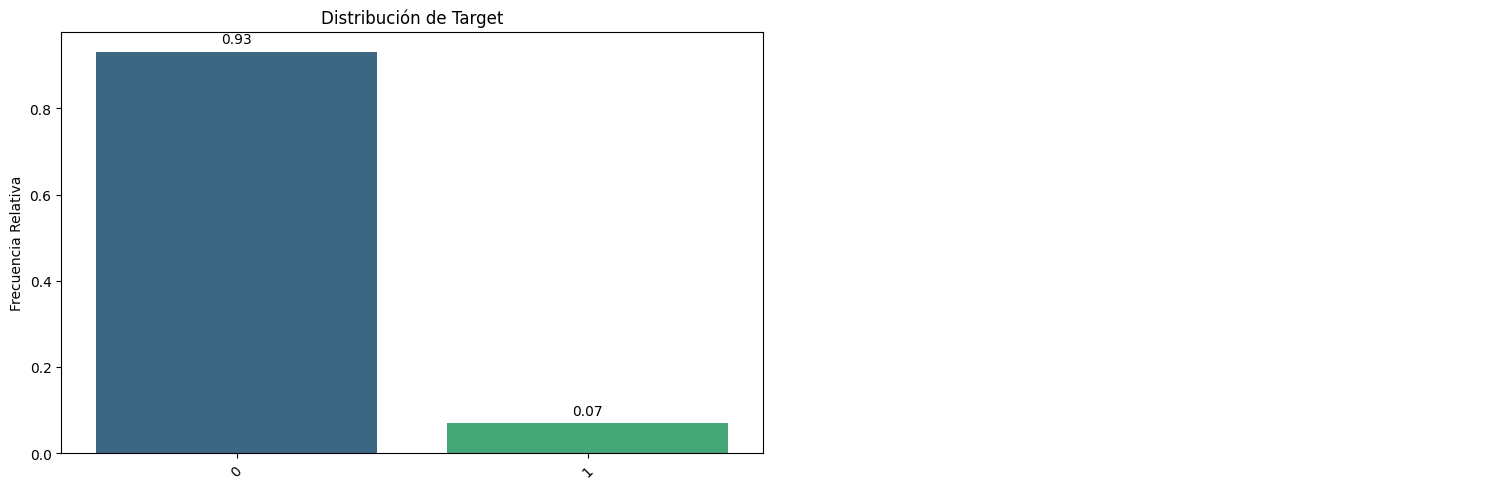

In [8]:
pinta_distribucion_categoricas(df, ['Target'], relativa=True, mostrar_valores=True)

Vemos claramente que nuestra variable Target está muy desequilibrada.
Hay muy pocos clientes con dificultades financieras en los últimos 2 años

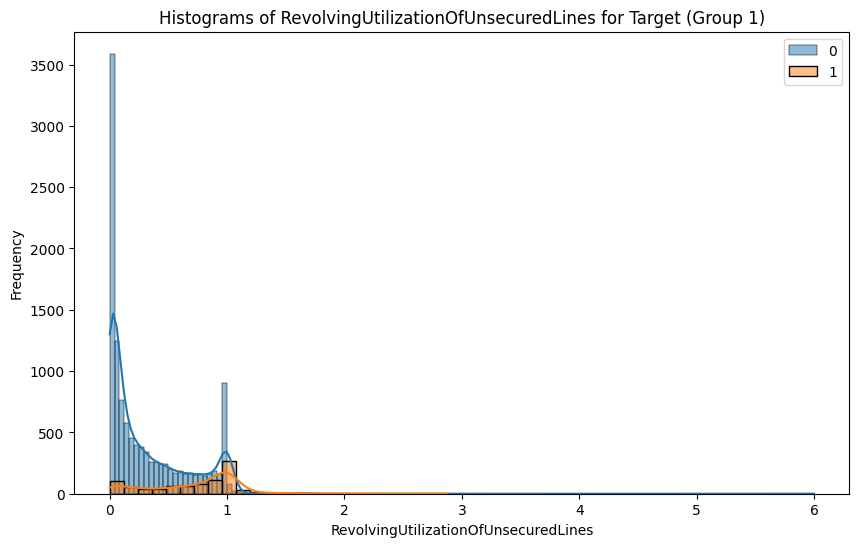

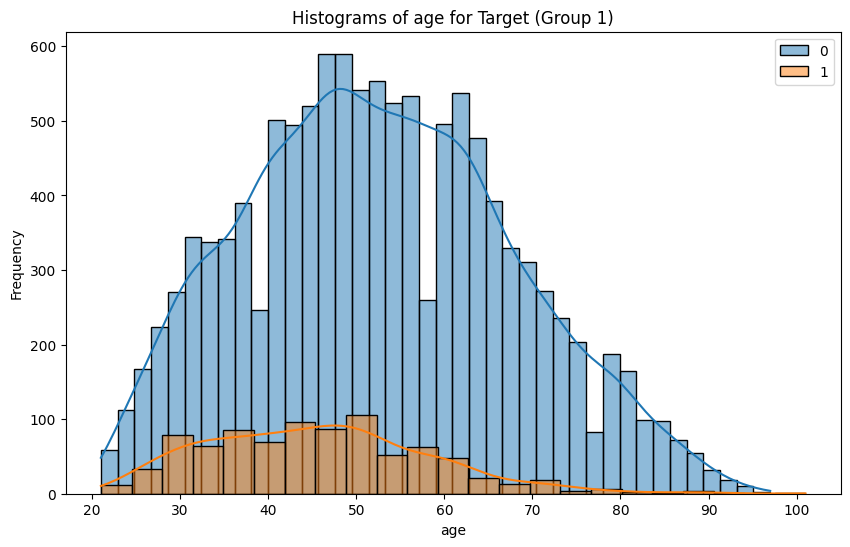

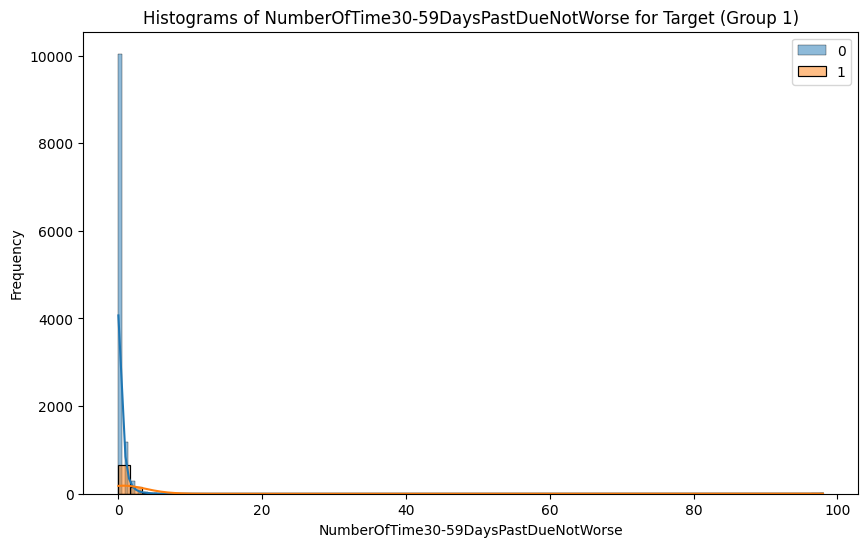

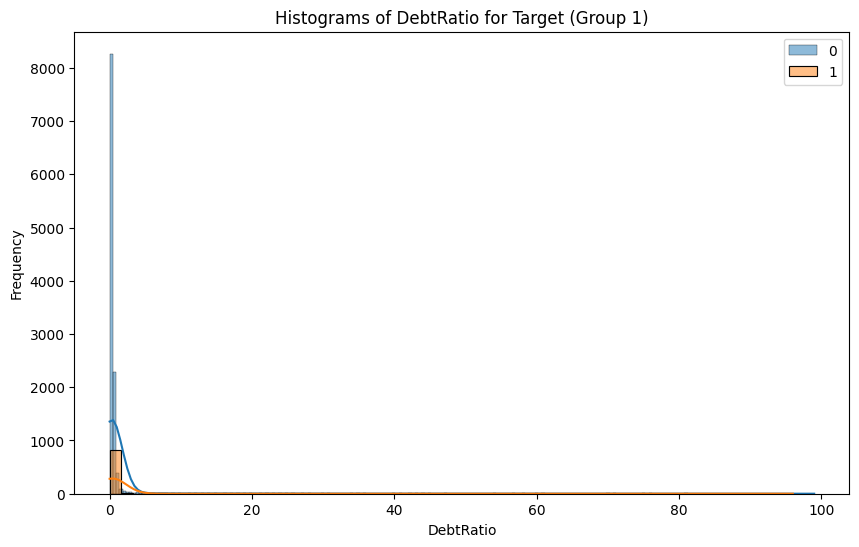

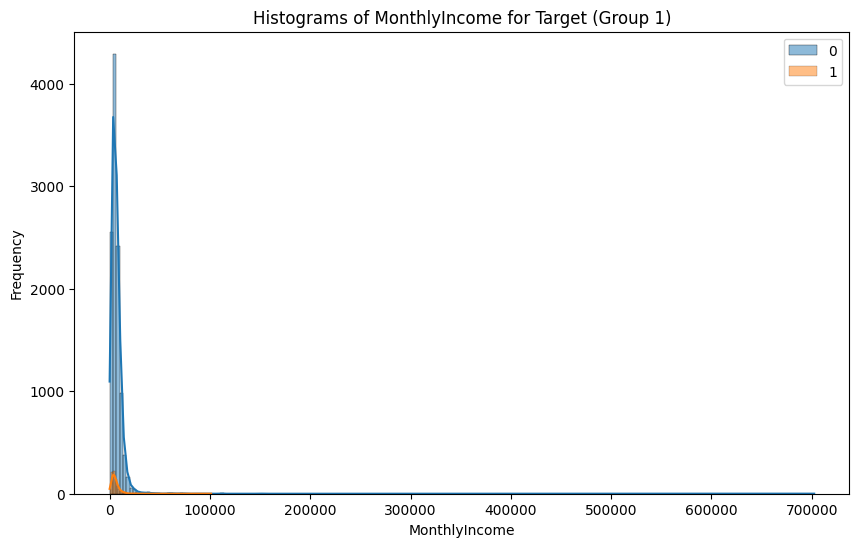

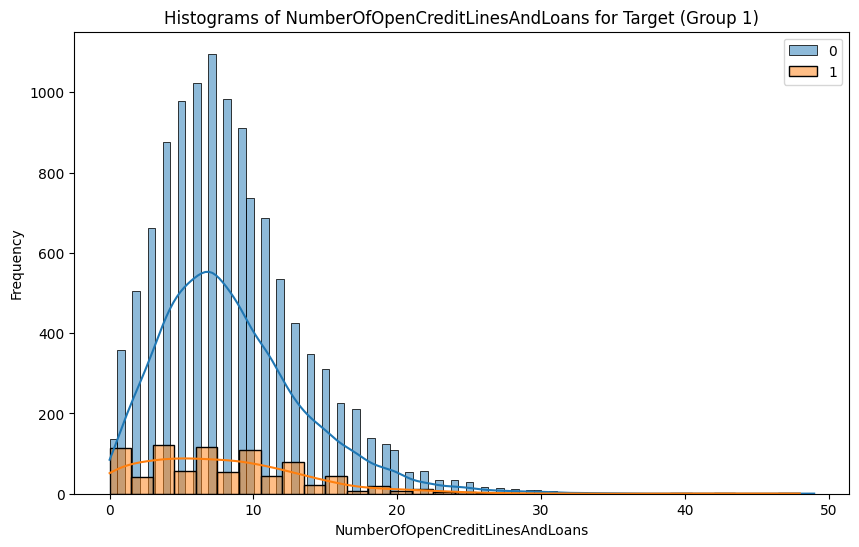

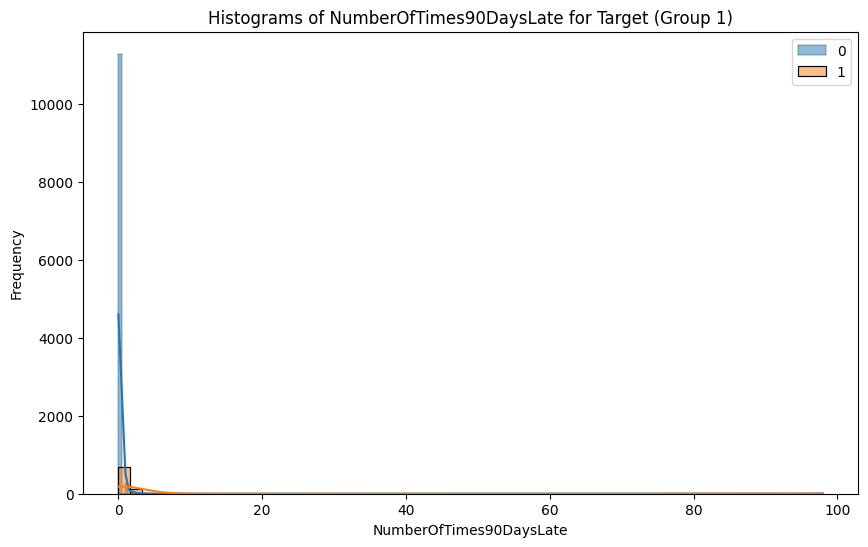

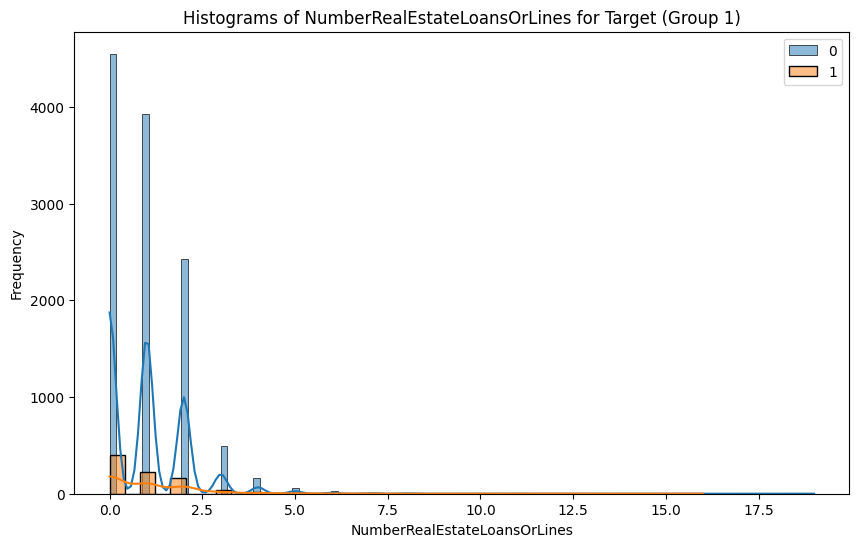

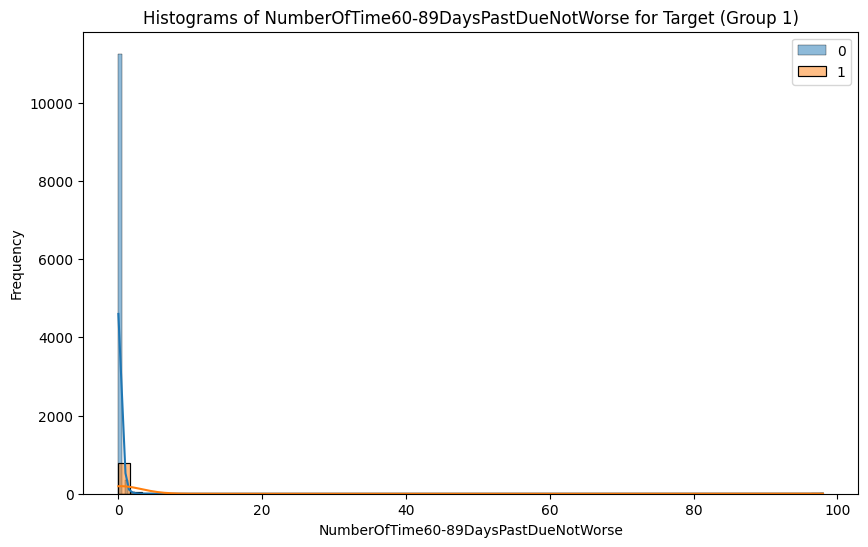

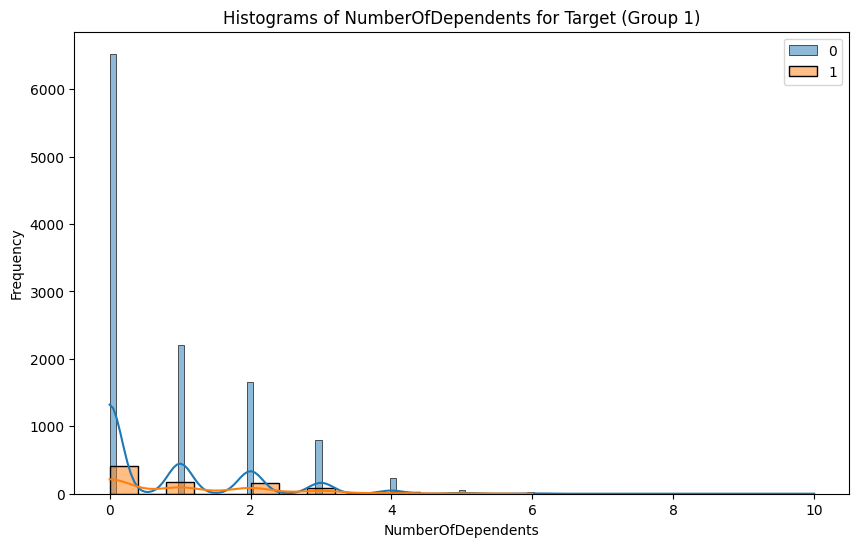

In [9]:
# Relación entre Target y numéricas
columnas_numericas = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

for numerical_col in columnas_numericas:
    #plot_categorical_numerical_relationship(df, 'Target', numerical_col, show_values=False, measure='mean')
    plot_grouped_histograms(df, 'Target', numerical_col, 2)
   

Veo superposiciones entre el valor de las features para los 2 posibles valores de Target --> me quedo cpn todas

In [10]:
df["NumberRealEstateLoansOrLines"].value_counts()

NumberRealEstateLoansOrLines
0     4947
1     4156
2     2585
3      530
4      179
5       74
6       27
7       13
8        9
9        4
11       4
12       3
16       2
10       2
19       1
13       1
Name: count, dtype: int64

c:\Users\jvend\OneDrive\Desktop\BootCampDS\MyBootCampDS\04_Machine_Learning\Sprint_12\Unidad_01_ML_Supervisado_Otros_Modelos\03_Practica_Obligatoria\bootcampviztools.py:45: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  count_data = df.groupby([cat_col1, cat_col2]).size().reset_index(name='count')


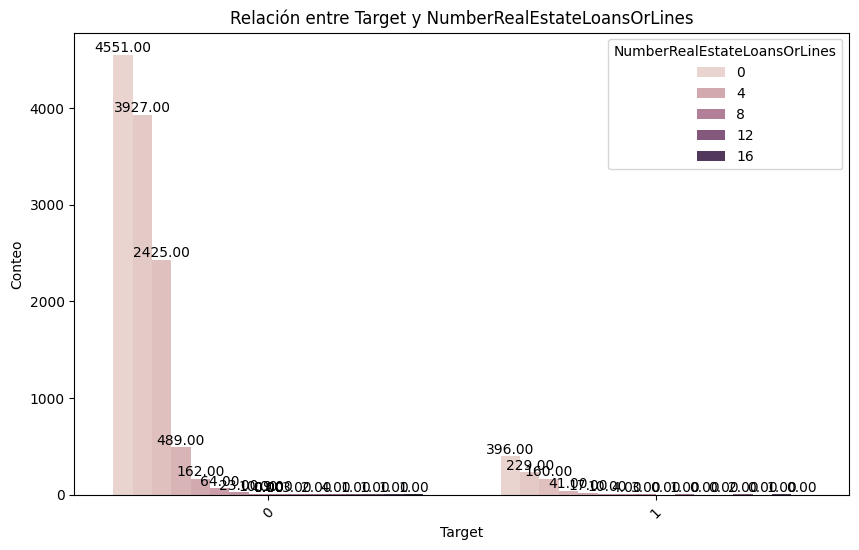

In [11]:
plot_categorical_relationship_fin(df, 'Target', 'NumberRealEstateLoansOrLines', show_values=True)

### #2 Modelado

Realiza un proceso completo de modelado hasta dar con el mejor modelo de los que hayas escogido (emplea al menos 3, y uno tiene que ser KNN). Aplica las técnicas que creas necesarias para obtener el mejor resultado (suponiendo que este después de hablar con el negocio es el recall medio, para tener un compromiso entre las dos clases). Para comparar modelos emplea validación cruzada antes de optimización y luego ajusta los hiperparámetros del mejor modelo. Evalúa este y haz un pequeño análisis de errores.

In [12]:
# Hacemos el split
train_set, test_set = train_test_split(df, test_size= 0.2, random_state= 42)


In [13]:
# Vemos que el ingreso mensual tiene valores nulos
df["MonthlyIncome"].isnull().sum()

np.int64(721)

In [14]:
# Los remplazamos por la mediana, ya que es una variable continua
train_set["MonthlyIncome"] = train_set["MonthlyIncome"].fillna(train_set["MonthlyIncome"].median())
test_set["MonthlyIncome"] = test_set["MonthlyIncome"].fillna(test_set["MonthlyIncome"].median())


In [15]:
# Vemos que el número de personas dependientes también tiene valores nulos
df["NumberOfDependents"].isnull().sum()


np.int64(177)

In [16]:
df["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     6935
1.0     2384
2.0     1816
3.0      882
4.0      253
5.0       62
6.0       24
8.0        2
10.0       1
7.0        1
Name: count, dtype: int64

In [17]:
train_set["NumberOfDependents"].mode()[0]

np.float64(0.0)

In [18]:
# Como es numérica discreta (tiene sólo 10 catergorías), remplazamos los nulos por la moda
train_set["NumberOfDependents"] = train_set["NumberOfDependents"].fillna(train_set["NumberOfDependents"].mode()[0])
test_set["NumberOfDependents"] = test_set["NumberOfDependents"].fillna(test_set["NumberOfDependents"].mode()[0])

In [19]:
train_set["NumberOfDependents"].value_counts()

NumberOfDependents
0.0     5700
1.0     1898
2.0     1462
3.0      698
4.0      197
5.0       52
6.0       19
10.0       1
7.0        1
8.0        1
Name: count, dtype: int64

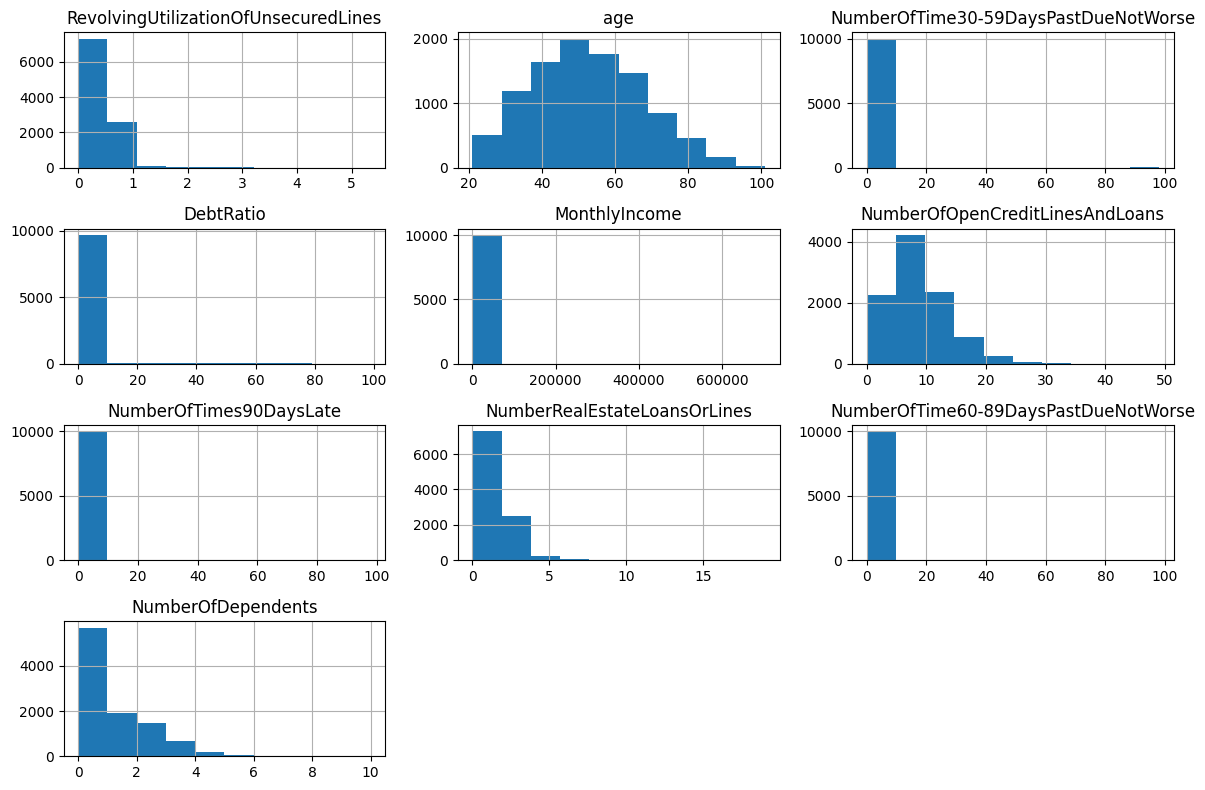

In [20]:
# Distribución de las features numéricas
train_set[columnas_numericas].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [21]:
# Todas las features excepto age, tienen una distribución muy sesgada a la derecha.
# Aplicamos una transformación logarítmica para reducir el sesgo

for col in columnas_numericas:
    if col != 'age':
        train_set[col] = np.log1p(train_set[col])
        test_set[col] = np.log1p(test_set[col])

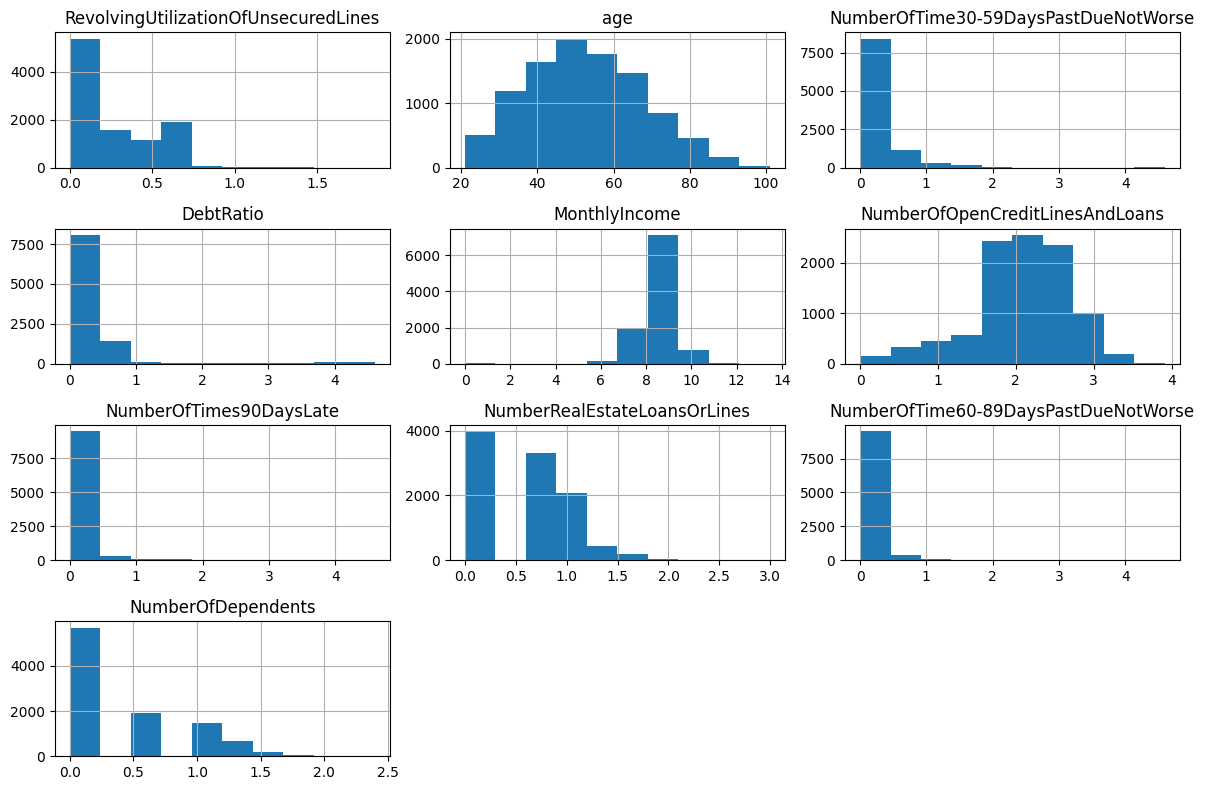

In [22]:
train_set[columnas_numericas].hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [23]:
# Modelo KNN: sensible a la escala de las variables
# Escalamos las variables numéricas

train_set_scaled = train_set.copy()
test_set_scaled = test_set.copy()

scaler = StandardScaler()

train_set_scaled[columnas_numericas] = scaler.fit_transform(train_set[columnas_numericas])
test_set_scaled[columnas_numericas] = scaler.transform(test_set[columnas_numericas])

In [24]:
# Extraemos la columna target del grupo X y la dejamos en y
X_train_scaled = train_set_scaled.drop("Target", axis = 1)
y_train_scaled = train_set_scaled["Target"]
X_test_scaled = test_set_scaled.drop("Target", axis = 1)
y_test_scaled = test_set_scaled["Target"]

In [25]:
# Hacemos lo mismo para el grupo sin escalar ya que usaremos otros modelos que no necesitan escala pq tienen 
# el hiperparámetro class_weight='balanced'

# Extraemos la columna target del grupo X y la dejamos en y
X_train = train_set.drop("Target", axis = 1)
y_train = train_set["Target"]
X_test = test_set.drop("Target", axis = 1)
y_test = test_set["Target"]

In [26]:
# Como no existe el hiperparámetro class_weight en este tipo de modelo
# Haremos primero un sobremuestreo y después un bajomuestreo para quedarnos con el mejor para equilibrar
# la clase minoritaria.

# Aplicar SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train_scaled)

In [27]:
# Comprobamos que ahora la Target está balanceada y que el número de muestras ha aumentado
print(f"Balanceo Target: {y_train_smote.value_counts(True)}")
print(f"\nMuestras iniciales: {X_train_scaled.shape}")
print(f"Muestras smote: {X_train_smote.shape}")

Balanceo Target: Target
0    0.5
1    0.5
Name: proportion, dtype: float64

Muestras iniciales: (10029, 10)
Muestras smote: (18656, 10)


In [28]:

knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_smote, y_train_smote)
y_pred = knn.predict(X_train_smote)
print(classification_report(y_train_smote, y_pred))
print(np.mean(cross_val_score(knn, X_train_smote, y_train_smote, cv = 5, scoring = "balanced_accuracy")))

              precision    recall  f1-score   support

           0       0.99      0.85      0.91      9328
           1       0.87      0.99      0.93      9328

    accuracy                           0.92     18656
   macro avg       0.93      0.92      0.92     18656
weighted avg       0.93      0.92      0.92     18656

0.8954758353950616


In [29]:
mejor_cvs = 0
mejor_k = 0

# Mejor cross_val_score para k entre 1 y 20
for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_smote, y_train_smote)
    y_pred = knn.predict(X_train_smote)
    # print(f"\nclassification_report para k={k}:\n{classification_report(y_train, y_pred)}")
    # print(f"\ncross_val_score para k={k}: {np.mean(cross_val_score(knn, X_train_smote, y_train_smote, cv = 5, scoring = 'balanced_accuracy'))}")
    
    cvs = np.mean(cross_val_score(knn, X_train_smote, y_train_smote, cv = 5, scoring = 'balanced_accuracy'))

    if cvs > mejor_cvs:
        mejor_cvs = cvs
        mejor_k = k
        report = classification_report(y_train_smote, y_pred)

print(f"\nMejor k: {mejor_k} con cross_val_score: {mejor_cvs}")
print(f"\nclassification_report para k={mejor_k}:\n{report}")


Mejor k: 2 con cross_val_score: 0.9384108744314084

classification_report para k=2:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      9328
           1       1.00      0.99      0.99      9328

    accuracy                           0.99     18656
   macro avg       0.99      0.99      0.99     18656
weighted avg       0.99      0.99      0.99     18656



In [30]:
# Bajomuestreo
# Separar las clases mayoritaria y minoritaria
clase_mayoritaria = X_train_scaled[y_train == 0]
clase_minoritaria = X_train_scaled[y_train == 1]

print(f"Número de muestras clase mayoritaria: {len(clase_mayoritaria)}")
print(f"Número de muestras clase minoritaria: {len(clase_minoritaria)}")

# Bajomuestrear la clase mayoritaria
clase_mayoritaria_bajomuestreo = resample(clase_mayoritaria,
                                          replace=False,
                                          n_samples=len(clase_minoritaria),  # igual al número de la clase minoritaria
                                          random_state=42)

# Combinar la clase minoritaria con la clase mayoritaria bajomuestreada (importante es que resample mantiene los índices para que lo que viene a continuación tenga sentido)
X_train_bajomuestreo = pd.concat([clase_mayoritaria_bajomuestreo, clase_minoritaria])
y_train_bajomuestreo = pd.concat([y_train_scaled.loc[clase_mayoritaria_bajomuestreo.index], 
                                  y_train_scaled.loc[clase_minoritaria.index]])

# Comprobamos que ahora la Target está balanceada y que el número de muestras ha dis
print(f"Balanceo Target: {y_train_bajomuestreo.value_counts(True)}")
print(f"\nMuestras iniciales: {X_train_scaled.shape}")
print(f"Muestras bajomuestreo: {X_train_bajomuestreo.shape}")

Número de muestras clase mayoritaria: 9328
Número de muestras clase minoritaria: 701
Balanceo Target: Target
0    0.5
1    0.5
Name: proportion, dtype: float64

Muestras iniciales: (10029, 10)
Muestras bajomuestreo: (1402, 10)


In [31]:
mejor_cvs = 0
mejor_k = 0

# Mejor cross_val_score para k entre 1 y 20
for k in range(1, 21):

    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_bajomuestreo, y_train_bajomuestreo)
    y_pred = knn.predict(X_train_bajomuestreo)
    # print(f"\nclassification_report para k={k}:\n{classification_report(y_train, y_pred)}")
    # print(f"\ncross_val_score para k={k}: {np.mean(cross_val_score(knn, X_train_bajomuestreo, y_train_bajomuestreo, cv = 5, scoring = 'balanced_accuracy'))}")
    
    cvs = np.mean(cross_val_score(knn, X_train_bajomuestreo, y_train_bajomuestreo, cv = 5, scoring = 'balanced_accuracy'))

    if cvs > mejor_cvs:
        mejor_cvs = cvs
        mejor_k = k
        report = classification_report(y_train_bajomuestreo, y_pred)

print(f"\nMejor k: {mejor_k} con cross_val_score: {mejor_cvs}")
print(f"\nclassification_report para k={mejor_k}:\n{report}")


Mejor k: 15 con cross_val_score: 0.7767223910840931

classification_report para k=15:
              precision    recall  f1-score   support

           0       0.79      0.83      0.81       701
           1       0.82      0.77      0.80       701

    accuracy                           0.80      1402
   macro avg       0.80      0.80      0.80      1402
weighted avg       0.80      0.80      0.80      1402



In [32]:
# Regresión Logística con con class_weight='balanced'
log_reg = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train_scaled) 
print(classification_report(y_train_scaled, log_reg.predict(X_train_scaled)))
print(np.mean(cross_val_score(log_reg, X_train_scaled, y_train_scaled, cv = 5, scoring = "balanced_accuracy")))


              precision    recall  f1-score   support

           0       0.98      0.80      0.88      9328
           1       0.22      0.75      0.34       701

    accuracy                           0.80     10029
   macro avg       0.60      0.78      0.61     10029
weighted avg       0.92      0.80      0.84     10029

0.7675397937381716


In [33]:
# Support Vector Classifier (SVC)
svc = SVC(class_weight='balanced', random_state=42)
svc.fit(X_train_scaled, y_train_scaled) 
print(classification_report(y_train_scaled, svc.predict(X_train_scaled)))
print(np.mean(cross_val_score(svc, X_train_scaled, y_train_scaled, cv = 5, scoring = "balanced_accuracy")))

              precision    recall  f1-score   support

           0       0.98      0.82      0.89      9328
           1       0.25      0.82      0.39       701

    accuracy                           0.82     10029
   macro avg       0.62      0.82      0.64     10029
weighted avg       0.93      0.82      0.86     10029

0.7650666129315508


In [39]:
# DecisionTreeClassifier
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier


param_grid_dt = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=3, scoring='balanced_accuracy')
dt_grid.fit(X_train_scaled, y_train_scaled)
print("Mejores parámetros DecisionTree:", dt_grid.best_params_)

dt_best = dt_grid.best_estimator_
y_pred_dt = dt_best.predict(X_test_scaled)
print("\nReporte de clasificación DecisionTree:\n", classification_report(y_test_scaled, y_pred_dt))
print("\nCross_val_score:", np.mean(cross_val_score(dt_best, X_train_scaled, y_train_scaled, cv = 5, scoring = "balanced_accuracy")))

# # RandomForestClassifier
# param_grid_rf = {
#     'n_estimators': [100, 200, 400],
#     'max_depth': [3, 5, 10, None],
#     'min_samples_leaf': [1, 5, 10],
#     'max_features': ['sqrt', 'log2', None]
# }
# rf_grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid_rf, cv=3, scoring='balanced_accuracy')
# rf_grid.fit(X_train_scaled, y_train_scaled)
# print("Mejores parámetros RandomForest:", rf_grid.best_params_)

# XGBoost
param_grid_xgb = {
    'n_estimators': [100, 200, 400],
    'max_depth': [3, 5, 10],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}
xgb_grid = RandomizedSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), param_grid_xgb, cv=3, n_iter=10, scoring='balanced_accuracy')
xgb_grid.fit(X_train_scaled, y_train_scaled)
print("\nMejores parámetros XGBoost:", xgb_grid.best_params_)

xgb_best = xgb_grid.best_estimator_
y_pred_xgb = xgb_best.predict(X_test_scaled)
print("\nReporte de clasificación XGBoost:\n", classification_report(y_test_scaled, y_pred_xgb))
print("\nCross_val_score:", np.mean(cross_val_score(xgb_best, X_train_scaled, y_train_scaled, cv = 5, scoring = "balanced_accuracy")))
# # LightGBM
# param_grid_lgb = {
#     'n_estimators': [100, 200, 400],
#     'max_depth': [3, 5, 10, -1],
#     'learning_rate': [0.01, 0.1, 0.2],
#     'num_leaves': [31, 50, 100]
# }
# lgb_grid = RandomizedSearchCV(LGBMClassifier(random_state=42), param_grid_lgb, cv=3, n_iter=10, scoring='balanced_accuracy')
# lgb_grid.fit(X_train_scaled, y_train_scaled)
# print("\nMejores parámetros LightGBM:", lgb_grid.best_params_)

# lgb_best = lgb_grid.best_estimator_
# y_pred_lgb = lgb_best.predict(X_test_scaled)
# print("\nReporte de clasificación LightGBM:\n", classification_report(y_test_scaled, y_pred_lgb))
# # CatBoost
# param_grid_cat = {
#     'depth': [3, 5, 10],
#     'iterations': [100, 200, 400],
#     'learning_rate': [0.01, 0.1, 0.2]
# }
# cat_grid = RandomizedSearchCV(CatBoostClassifier(random_state=42, verbose=False), param_grid_cat, cv=3, n_iter=10, scoring='balanced_accuracy')
# cat_grid.fit(X_train_scaled, y_train_scaled)
# print("Mejores parámetros CatBoost:", cat_grid.best_params_)


Mejores parámetros DecisionTree: {'max_depth': None, 'min_samples_leaf': 5, 'min_samples_split': 2}

Reporte de clasificación DecisionTree:
               precision    recall  f1-score   support

           0       0.95      0.96      0.95      2345
           1       0.30      0.27      0.28       163

    accuracy                           0.91      2508
   macro avg       0.62      0.61      0.62      2508
weighted avg       0.91      0.91      0.91      2508


Cross_val_score: 0.6061320913066208

Mejores parámetros XGBoost: {'subsample': 0.7, 'n_estimators': 400, 'max_depth': 3, 'learning_rate': 0.2, 'colsample_bytree': 0.7}

Reporte de clasificación XGBoost:
               precision    recall  f1-score   support

           0       0.95      0.98      0.96      2345
           1       0.46      0.23      0.31       163

    accuracy                           0.93      2508
   macro avg       0.70      0.61      0.64      2508
weighted avg       0.92      0.93      0.92      2508

